# Прогнозирование временных рядов (Bybit): единый Jupyter pipeline

Этот ноутбук переносит текущее решение в воспроизводимый формат:
- загрузка данных BTC/ETH с основного Bybit,
- очистка и предобработка,
- запуск моделей Naive / ARIMA,
- проверки, визуализация и экспорт результатов.

## 1) Подготовка окружения и зависимостей

Если чего-то не хватает, раскомментируй установку в ячейке ниже и перезапусти kernel.

In [53]:

# Глобальные флаги включения моделей
NAIVE_ENABLED = True
ARIMA_ENABLED = False
SARIMA_ENABLED = False
AST_ENABLED = False
NBEATS_ENABLED = True
LSTM_ENABLED = True

MODEL_FLAGS = {
    'naive': NAIVE_ENABLED,
    'arima': ARIMA_ENABLED,
    'sarima': SARIMA_ENABLED,
    'ast': AST_ENABLED,
    'nbeats': NBEATS_ENABLED,
    'lstm': LSTM_ENABLED,
}

In [54]:
# При необходимости установки (раскомментируй):
# %pip install pandas numpy requests statsmodels matplotlib seaborn torch

import sys
print('Python:', sys.version)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


## 2) Импорт модулей и базовые настройки

Задаём импорты, параметры отображения и конфигурацию загрузки данных.

In [62]:
from __future__ import annotations

import importlib
import os
import pandas as pd
import seaborn as sns
from pathlib import Path

from data_pipeline import DataConfig, DataProcessor, fetch_klines, build_datasets
import model_baselines as _mb
from export_utils import plot_result, export_all_results

# В ноутбуке иногда остаётся старый кэш модуля после правок файла — принудительно обновляем
_mb = importlib.reload(_mb)
run_naive = _mb.run_naive
run_arima = _mb.run_arima
run_sarima = _mb.run_sarima
run_nbeats = _mb.run_nbeats
run_lstm = _mb.run_lstm
run_lstm_gridsearchcv_native_pipeline = _mb.run_lstm_gridsearchcv_native_pipeline
run_naive_gridsearchcv_native_pipeline = _mb.run_naive_gridsearchcv_native_pipeline
run_arima_gridsearchcv_native_pipeline = _mb.run_arima_gridsearchcv_native_pipeline
run_sarima_gridsearchcv_native_pipeline = _mb.run_sarima_gridsearchcv_native_pipeline
run_nbeats_gridsearchcv_native_pipeline = _mb.run_nbeats_gridsearchcv_native_pipeline

# Inference-only API: fit в модельных блоках, predict в weekly-блоке (#8.1).
fit_naive_inference_model = _mb.fit_naive_inference_model
predict_naive_inference = _mb.predict_naive_inference
fit_arima_inference_model = _mb.fit_arima_inference_model
predict_arima_inference = _mb.predict_arima_inference
fit_sarima_inference_model = _mb.fit_sarima_inference_model
predict_sarima_inference = _mb.predict_sarima_inference
fit_nbeats_inference_model = _mb.fit_nbeats_inference_model
predict_nbeats_inference = _mb.predict_nbeats_inference
fit_lstm_inference_model = _mb.fit_lstm_inference_model
predict_lstm_inference = _mb.predict_lstm_inference

CPU_COUNT = int(os.cpu_count() or 8)
SAFE_CPU_WORKERS = max(1, min(16, CPU_COUNT - 1))

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='60',
    bars=30000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']
OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3) Загрузка входных данных/файлов

Скачиваем свечи с Bybit API и проверяем структуру.

In [56]:
raw_data = {}
LOCAL_DATA_DIR = Path('data')
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

for symbol in SYMBOLS:
    local_file = LOCAL_DATA_DIR / f"{symbol.lower()}_timeseries.csv"
    try:
        df = fetch_klines(symbol, CONFIG)
        if df is None or len(df) == 0:
            raise RuntimeError('Bybit вернул пустой датасет')

        raw_data[symbol] = df
        df.to_csv(local_file, index=False)
        print(f"{symbol}: {len(df)} rows (скачано с API, сохранено в {local_file})")
    except Exception as e:
        if local_file.exists():
            raw_data[symbol] = pd.read_csv(local_file)
            print(f"{symbol}: API недоступен ({e}), взято локально из {local_file}, rows={len(raw_data[symbol])}")
        else:
            raise RuntimeError(
                f"{symbol}: не удалось скачать с API и нет локального файла {local_file}. Ошибка API: {e}"
            )

raw_data['BTCUSDT'].head()

BTCUSDT: 30000 rows (скачано с API, сохранено в data\btcusdt_timeseries.csv)
ETHUSDT: 30000 rows (скачано с API, сохранено в data\ethusdt_timeseries.csv)


,timestamp,open,high,low,close,volume,turnover
0,2022-10-05 12:00:00+00:00,20018.0,20058.0,19955.0,20011.5,6932.789,1.387366e+08
1,2022-10-05 13:00:00+00:00,20011.5,20029.0,19811.5,19909.5,25011.373,4.976903e+08
2,2022-10-05 14:00:00+00:00,19909.5,19933.0,19734.5,19871.0,21358.292,4.235006e+08
3,2022-10-05 15:00:00+00:00,19871.0,20017.0,19853.0,19990.5,10420.470,2.078438e+08
4,2022-10-05 16:00:00+00:00,19990.5,20283.0,19947.5,20220.0,24308.617,4.894560e+08


## 4) Очистка и предобработка данных

Убираем некорректные значения, нули и экстремальные выбросы по лог-доходности.

In [57]:
processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}

for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f"{symbol}: before={rep['initial_rows']} after={rep['final_rows']} removed={rep['removed_total']} "
        f"(zero/nonpos={rep['removed_nonpositive_or_zero']}, outliers={rep['removed_outliers']})"
    )

cleaned_data['BTCUSDT'].head()

BTCUSDT: before=30000 after=29839 removed=161 (zero/nonpos=0, outliers=161)
ETHUSDT: before=30000 after=29851 removed=149 (zero/nonpos=0, outliers=149)


,timestamp,open,high,low,close,volume,turnover
0,2022-10-05 12:00:00+00:00,20018.0,20058.0,19955.0,20011.5,6932.789,1.387366e+08
1,2022-10-05 13:00:00+00:00,20011.5,20029.0,19811.5,19909.5,25011.373,4.976903e+08
2,2022-10-05 14:00:00+00:00,19909.5,19933.0,19734.5,19871.0,21358.292,4.235006e+08
3,2022-10-05 15:00:00+00:00,19871.0,20017.0,19853.0,19990.5,10420.470,2.078438e+08
4,2022-10-05 16:00:00+00:00,19990.5,20283.0,19947.5,20220.0,24308.617,4.894560e+08


## 5) Основная логика (функции и вычисления)

Разбиваем данные на train/test и реализуем запуск моделей.

In [58]:
datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f"{symbol}: full={len(data['full'])} train={len(data['train'])} test={len(data['test'])}")

BTCUSDT: full=29839 train=23871 test=5968
ETHUSDT: full=29851 train=23880 test=5971


## 6) Проверка результата и отладочные проверки

Быстрые assert-проверки целостности данных и базового запуска.

In [59]:
for symbol in SYMBOLS:
    assert symbol in datasets, f'{symbol} отсутствует в datasets'
    assert len(datasets[symbol]['train']) > 10, f'{symbol}: слишком мало train данных'
    assert len(datasets[symbol]['test']) > 10, f'{symbol}: слишком мало test данных'
    assert (datasets[symbol]['full'] > 0).all(), f'{symbol}: есть неположительные значения после очистки'

print('Базовые проверки данных пройдены.')

# smoke-test на Naive
smoke_symbol = 'BTCUSDT'
smoke_metrics, smoke_pred = run_naive(datasets[smoke_symbol]['train'], datasets[smoke_symbol]['test'])
print('Smoke Naive metrics:', smoke_metrics)
smoke_pred.head()

Базовые проверки данных пройдены.
Smoke Naive metrics: {'MAE': 288.6534517426272, 'RMSE': 433.24550580194943, 'MAPE': 0.30102342021663614}


,y_true,y_pred
0,105584.6,105749.9
1,105634.8,105584.6
2,105340.0,105634.8
3,105668.5,105340.0
4,105857.4,105668.5


## 7) Визуализация результатов

Строим график исходного ряда и сравнение факта/прогноза для выбранной модели.

In [60]:
# 1) Начальные данные
RUN_SYMBOL = 'BTCUSDT'  # BTCUSDT или ETHUSDT
ARIMA_ORDER = (1, 1, 1)
SARIMA_ORDER = (1, 1, 0)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 24)

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

ALL_RESULTS = {}
TRAINED_MODELS = {}

print(f'Готово к запуску моделей для {RUN_SYMBOL}')
print('Активные модели:', [m for m, enabled in MODEL_FLAGS.items() if enabled])

Готово к запуску моделей для BTCUSDT
Активные модели: ['naive', 'nbeats', 'lstm']


NAIVE HalvingGridSearchCV: train_points=23871 | test_points=5968 | n_splits=16


NAIVE HalvingGridSearchCV:   0%|          | 0/16 [00:00<?, ?fit/s]

n_iterations: 1
n_required_iterations: 1
n_possible_iterations: 6
min_resources_: 40
max_resources_: 23871
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1
n_resources: 40
Fitting 16 folds for each of 1 candidates, totalling 16 fits


NAIVE HalvingGridSearchCV: 100%|██████████| 16/16 [00:05<00:00,  2.93fit/s]

NAIVE split info: {'full_points': 29839, 'train_points': 23871, 'test_points': 5968, 'test_ratio': 0.2, 'cv_n_splits': 16}
NAIVE best params: {'strategy': 'last', 'resource_points': 40}


,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_strategy,param_resource_points,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,split10_test_score,split11_test_score,split12_test_score,split13_test_score,split14_test_score,split15_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0,40,0.00042,0.000071,0.005402,0.000283,last,40,"{'strategy': 'last', 'resource_points': 40}",-42.651353,-88.767094,-74.662963,-68.134972,-51.185755,-83.872792,-139.860541,-205.305342,-266.889103,-186.301994,-241.83839,-197.377066,-377.968305,-385.532194,-298.77094,-273.320726,-186.402471,110.168223,1,186.402471,110.168223


SYMBOL=BTCUSDT | MODEL=naive
Metrics: {'MAE': 288.6534517426272, 'RMSE': 433.24550580194943, 'MAPE': 0.30102342021663614}


,y_true,y_pred
0,105584.6,105749.9
1,105634.8,105584.6
2,105340.0,105634.8
3,105668.5,105340.0
4,105857.4,105668.5


,y_true,y_pred
5963,67274.9,67135.3
5964,67492.7,67274.9
5965,67659.1,67492.7
5966,67862.6,67659.1
5967,67482.9,67862.6


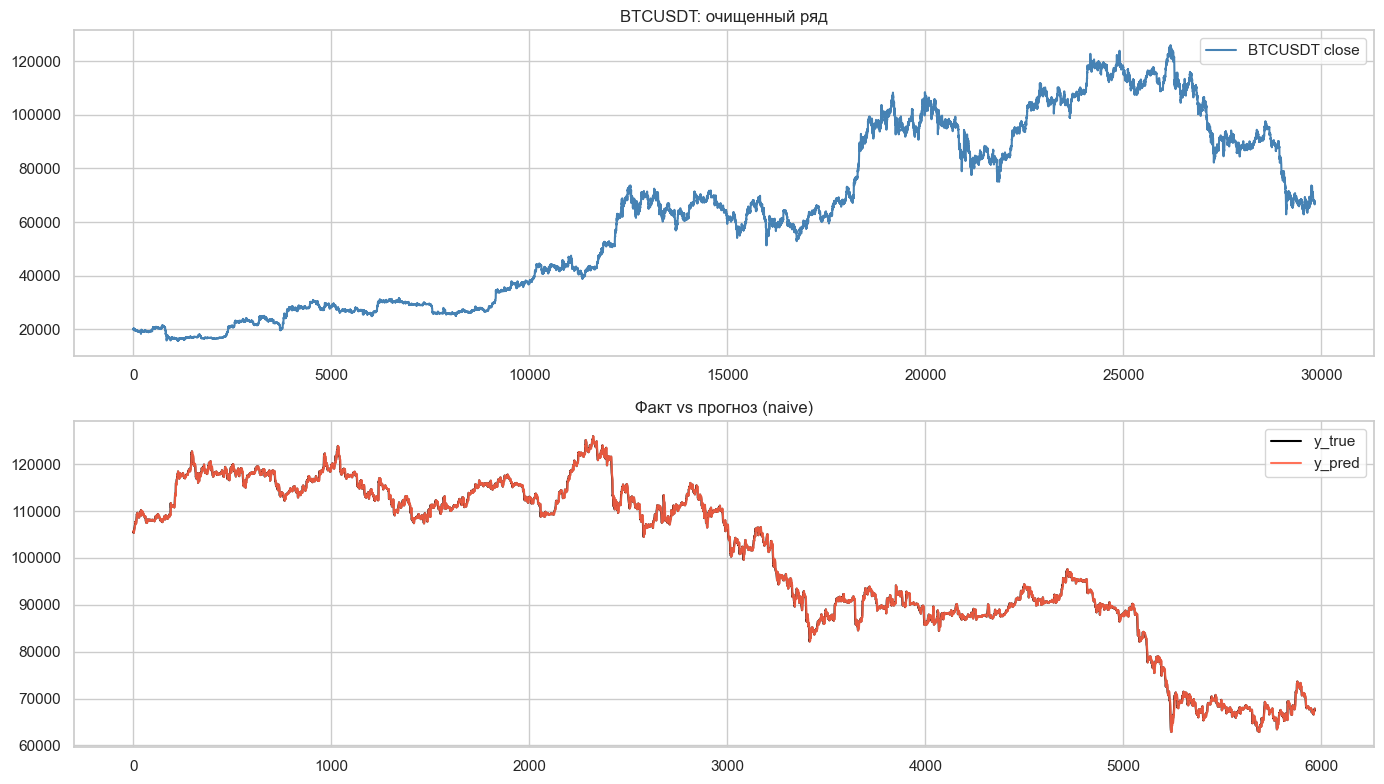

In [63]:
# 2) Модель Naive + native GridSearchCV
RUN_MODEL = 'naive'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    NAIVE_PARAM_GRID = {
        'strategy': ['last'],
    }
    NAIVE_CV_SPLITS = 16

    naive_best_params, naive_cv_df, model_metrics, pred_df, naive_split_info = run_naive_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=NAIVE_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=NAIVE_CV_SPLITS,
        scoring='MAE',
        n_jobs=SAFE_CPU_WORKERS,
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_naive_inference_model(train)

    print('NAIVE split info:', naive_split_info)
    print('NAIVE best params:', naive_best_params)
    display(naive_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

In [64]:
# 3) Модель ARIMA + native GridSearchCV
RUN_MODEL = 'arima'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    ARIMA_PARAM_GRID = {
        'p': [0, 1, 2],
        'd': [1],
        'q': [0, 1, 2],
        'refit_every': [24],
    }
    ARIMA_CV_SPLITS = 4
    ARIMA_UPDATE_STRIDE = 1

    arima_best_params, arima_cv_df, model_metrics, pred_df, arima_split_info = run_arima_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=ARIMA_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=ARIMA_CV_SPLITS,
        scoring='MAE',
        n_jobs=SAFE_CPU_WORKERS,
    )

    ARIMA_ORDER = (
        int(arima_best_params['p']),
        int(arima_best_params['d']),
        int(arima_best_params['q']),
    )
    ARIMA_HOLDOUT_REFIT_EVERY = int(arima_best_params.get('refit_every', 24))
    ARIMA_INFERENCE_REFIT_EVERY = 0

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_arima_inference_model(
        train,
        order=ARIMA_ORDER,
        update_stride=ARIMA_UPDATE_STRIDE,
        refit_every=ARIMA_INFERENCE_REFIT_EVERY,
    )

    print('ARIMA split info:', arima_split_info)
    print('ARIMA best params:', arima_best_params)
    print(
        f'ARIMA mode: update_stride={ARIMA_UPDATE_STRIDE}, '
        f'holdout_refit_every={ARIMA_HOLDOUT_REFIT_EVERY}, '
        f'inference_refit_every={ARIMA_INFERENCE_REFIT_EVERY}'
    )
    display(arima_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

SKIP: arima отключена (MODEL_FLAGS)


In [65]:
# 3.2) Модель SARIMA + native GridSearchCV
RUN_MODEL = 'sarima'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    SARIMA_PARAM_GRID = {
        'p': [1],
        'd': [1],
        'q': [0, 1],
        'sp': [1],
        'sd': [1],
        'sq': [0, 1],
        's': [24],
        'refit_every': [48],
        'fit_window': [1000],
        'maxiter': [50],
    }
    SARIMA_CV_SPLITS = 3

    sarima_best_params, sarima_cv_df, model_metrics, pred_df, sarima_split_info = run_sarima_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=SARIMA_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=SARIMA_CV_SPLITS,
        scoring='MAE',
        n_jobs=SAFE_CPU_WORKERS,
    )

    SARIMA_ORDER = (
        int(sarima_best_params['p']),
        int(sarima_best_params['d']),
        int(sarima_best_params['q']),
    )
    SARIMA_SEASONAL_ORDER = (
        int(sarima_best_params['sp']),
        int(sarima_best_params['sd']),
        int(sarima_best_params['sq']),
        int(sarima_best_params['s']),
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_sarima_inference_model(
        train, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER, maxiter=50
    )

    print('SARIMA split info:', sarima_split_info)
    print('SARIMA best params:', sarima_best_params)
    display(sarima_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

SKIP: sarima отключена (MODEL_FLAGS)


In [66]:
# 3.5) Модель AST + native GridSearchCV

from experiment_blocks import run_ast_gridsearchcv_native_pipeline



RUN_MODEL = 'ast'



if not MODEL_FLAGS.get(RUN_MODEL, True):

    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')

else:

    # Подстраиваем сетку под текущую длину ряда, чтобы не падать на коротких сериях

    train_points_est = int(len(full) * (1.0 - CONFIG.test_ratio))

    max_context_allowed = max(48, train_points_est - 40)

    candidate_context = [72, 96, 120, 168]

    ast_contexts = [c for c in candidate_context if c <= max_context_allowed]

    if not ast_contexts:

        ast_contexts = [max(48, min(72, max_context_allowed))]



    AST_USE_CUDA = False



    # Практичная сетка для AST (умеренное число комбинаций)

    AST_PARAM_GRID = {

        'context_len': ast_contexts,

        'pred_len': [1],

        'epochs': [20],

        'batch_size': [64],

        'lr': [6e-4],

        'min_lr': [1e-5],

        'lambda_adv': [0.006, 0.008],

        'd_steps': [1],

        'd_model': [96, 128],

        'n_heads': [4, 8],

        'n_layers': [2],

        'ff_dim': [192],

        'dropout': [0.10, 0.12],

        'topk': [24],

        'use_amp': [False],

        'use_gan': ['auto'],

    }

    AST_CV_SPLITS = 3 if len(full) >= 1200 else 2



    print(f'AST auto-config: len(full)={len(full)}, context_len={ast_contexts}, cv_splits={AST_CV_SPLITS}, use_cuda={AST_USE_CUDA}')



    ast_best_params, ast_cv_df, model_metrics, pred_df, ast_split_info = run_ast_gridsearchcv_native_pipeline(

        full_series=full,

        param_grid=AST_PARAM_GRID,

        test_ratio=CONFIG.test_ratio,

        n_splits=AST_CV_SPLITS,

        scoring='MAE',

        use_cuda=AST_USE_CUDA,

        n_jobs=1,

    )



    ALL_RESULTS[RUN_MODEL] = {

        'metrics': model_metrics,

        'pred_df': pred_df.copy(),

        'symbol': RUN_SYMBOL,

    }



    print('AST split info:', ast_split_info)

    print('AST best params:', ast_best_params)

    display(ast_cv_df.head(20))

    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')

    print('Metrics:', model_metrics)

    display(pred_df.head())

    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)


SKIP: ast отключена (MODEL_FLAGS)


NBEATS device: cpu
NBEATS GridSearch config: use_cuda=False, n_jobs=16
NBEATS HalvingGridSearchCV: train_points=23871 | test_points=5968 | n_splits=3


NBEATS HalvingGridSearchCV:   0%|          | 0/294 [00:00<?, ?fit/s]

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 5
min_resources_: 160
max_resources_: 23871
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 64
n_resources: 160
Fitting 3 folds for each of 64 candidates, totalling 192 fits


NBEATS HalvingGridSearchCV:  61%|██████    | 178/294 [00:13<00:01, 109.52fit/s]

----------
iter: 1
n_candidates: 22
n_resources: 480
Fitting 3 folds for each of 22 candidates, totalling 66 fits


...

NBEATS HalvingGridSearchCV: best MAE=226.427170 | {'batch_size': 128, 'context_len': 120, 'epochs': 16, 'layer_size': 256, 'layers': 4, 'lr': 0.0006, 'n_blocks': 3, 'resource_points': 4320}
NBEATS device: cpu
NBEATS split info: {'full_points': 29839, 'train_points': 23871, 'test_points': 5968, 'test_ratio': 0.2, 'cv_n_splits': 3}
NBEATS best params: {'batch_size': 128, 'context_len': 120, 'epochs': 16, 'layer_size': 256, 'layers': 4, 'lr': 0.0006, 'n_blocks': 3, 'resource_points': 4320}


,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_context_len,param_epochs,param_layer_size,param_layers,param_lr,param_n_blocks,param_resource_points,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,3,4320,0.000463,0.000097,9.168451,0.051629,128,120,16,256,4,0.0006,3,4320,"{'batch_size': 128, 'context_len': 120, 'epoch...",-94.239444,-232.621509,-352.420557,-226.427170,105.492967,1,226.427170,105.492967
1,2,1440,0.000467,0.000176,5.750970,0.946666,128,120,16,256,4,0.0006,3,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-117.846731,-255.865485,-329.809890,-234.507369,87.841608,2,234.507369,87.841608
2,3,4320,0.000561,0.000151,9.510635,0.025821,128,120,16,192,4,0.0010,4,4320,"{'batch_size': 128, 'context_len': 120, 'epoch...",-122.369625,-247.681616,-341.646977,-237.232739,89.823989,3,237.232739,89.823989
3,2,1440,0.000206,0.000019,5.285788,0.254460,128,120,16,192,4,0.0006,3,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-155.863303,-256.793681,-334.104788,-248.920591,72.979430,4,248.920591,72.979430
4,3,4320,0.000477,0.000106,7.271890,0.023314,128,120,16,192,4,0.0006,3,4320,"{'batch_size': 128, 'context_len': 120, 'epoch...",-96.006567,-344.432000,-346.970282,-262.469616,117.711713,5,262.469616,117.711713
5,2,1440,0.000182,0.000022,7.135740,0.181560,128,120,16,192,4,0.0010,4,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-149.226975,-270.848564,-385.018249,-268.364596,96.277408,6,268.364596,96.277408
6,2,1440,0.000320,0.000032,5.478927,0.065424,128,120,16,192,4,0.0006,4,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-229.459570,-229.772657,-442.550970,-300.594399,100.378535,7,300.594399,100.378535
7,2,1440,0.000361,0.000095,6.404356,0.105931,128,120,16,256,4,0.0010,4,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-129.300223,-359.598277,-431.650409,-306.849636,128.946302,8,306.849636,128.946302
8,1,480,0.000315,0.000008,4.949067,0.127255,128,120,16,256,4,0.0010,4,480,"{'batch_size': 128, 'context_len': 120, 'epoch...",-186.316369,-416.210908,-340.681047,-314.402774,95.675791,9,314.402774,95.675791
9,2,1440,0.000206,0.000005,10.442048,0.046834,128,120,24,256,4,0.0006,4,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-189.218019,-235.194807,-661.194236,-361.869021,212.485536,10,361.869021,212.485536


SYMBOL=BTCUSDT | MODEL=nbeats
Metrics: {'MAE': 288.997078612091, 'RMSE': 433.3089987772395, 'MAPE': 0.30131701664449306}


,y_true,y_pred
0,105584.6,105736.170699
1,105634.8,105571.408100
2,105340.0,105621.500618
3,105668.5,105326.906567
4,105857.4,105655.398706


,y_true,y_pred
5963,67274.9,67125.798725
5964,67492.7,67264.785483
5965,67659.1,67483.234521
5966,67862.6,67649.188681
5967,67482.9,67852.586044


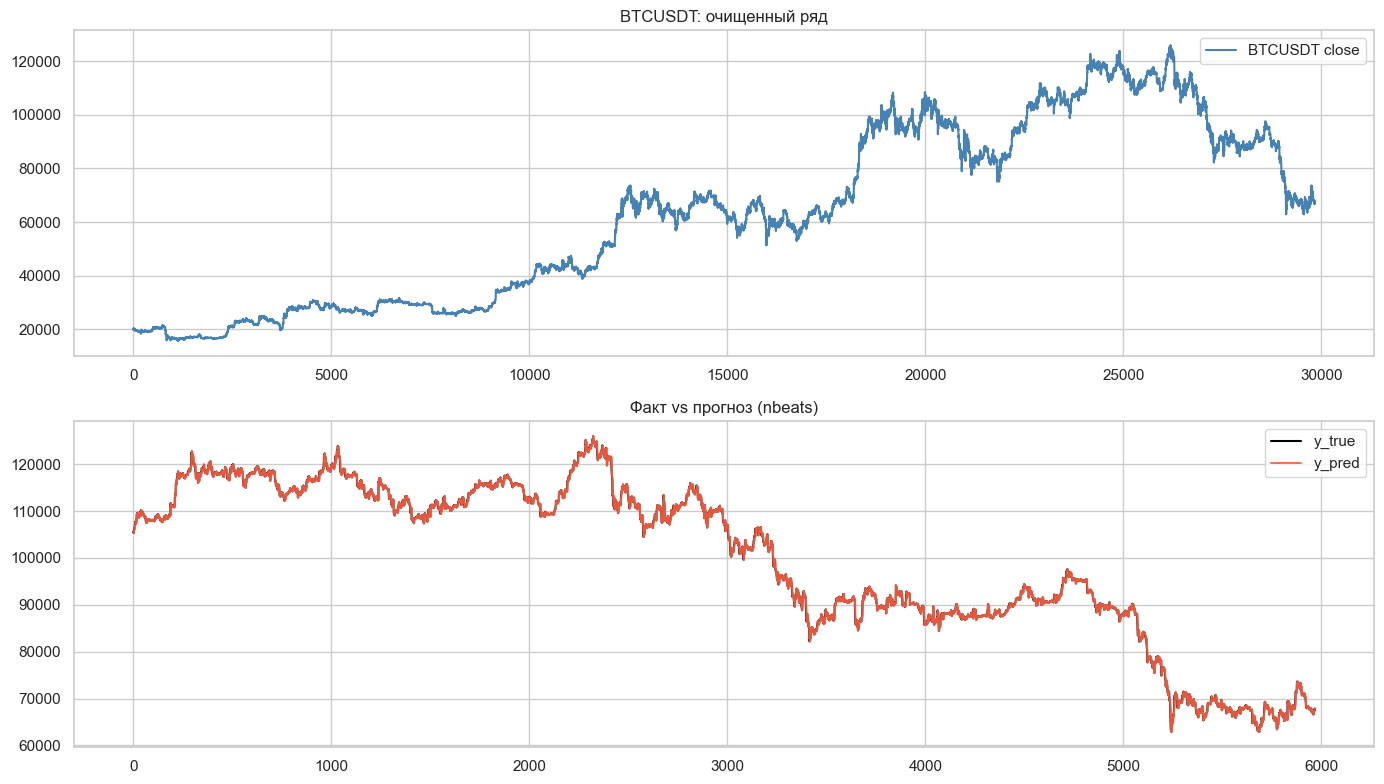

In [67]:
# 3.7) Модель N-BEATS (5-я модель) + native GridSearchCV
RUN_MODEL = 'nbeats'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    import torch

    NBEATS_USE_CUDA = False #torch.cuda.is_available()
    if NBEATS_USE_CUDA:
        print('NBEATS device:', torch.cuda.get_device_name(0))
    else:
        print('NBEATS device: cpu')

    NBEATS_PARAM_GRID = {
        'context_len': [120, 168],
        'n_blocks': [3, 4],
        'layers': [3, 4],
        'layer_size': [192, 256],
        'epochs': [16, 24],
        'batch_size': [128],
        'lr': [6e-4, 1e-3],
    }
    NBEATS_CV_SPLITS = 3

    nbeats_grid_jobs = 1 if NBEATS_USE_CUDA else SAFE_CPU_WORKERS
    print(f'NBEATS GridSearch config: use_cuda={NBEATS_USE_CUDA}, n_jobs={nbeats_grid_jobs}')

    nbeats_best_params, nbeats_cv_df, model_metrics, pred_df, nbeats_split_info = run_nbeats_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=NBEATS_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=NBEATS_CV_SPLITS,
        scoring='MAE',
        use_cuda=NBEATS_USE_CUDA,
        n_jobs=nbeats_grid_jobs,
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_nbeats_inference_model(
        train,
        context_len=int(nbeats_best_params['context_len']),
        n_blocks=int(nbeats_best_params['n_blocks']),
        layers=int(nbeats_best_params['layers']),
        layer_size=int(nbeats_best_params['layer_size']),
        epochs=int(nbeats_best_params['epochs']),
        batch_size=int(nbeats_best_params['batch_size']),
        lr=float(nbeats_best_params['lr']),
        weight_decay=float(nbeats_best_params.get('weight_decay', 1e-4)),
        use_cuda=bool(NBEATS_USE_CUDA),
    )

    print('NBEATS split info:', nbeats_split_info)
    print('NBEATS best params:', nbeats_best_params)
    display(nbeats_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

In [ ]:
# 3.9) Модель LSTM (6-я модель) + native sklearn HalvingGridSearchCV
import torch

RUN_MODEL = 'lstm'
if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    LSTM_SCORING = 'MAE'
    LSTM_GPU_SWITCH_THRESHOLD = 50_000
    LSTM_USE_CUDA = bool(len(full) > LSTM_GPU_SWITCH_THRESHOLD and torch.cuda.is_available())
    LSTM_GRID_N_JOBS = 1 if LSTM_USE_CUDA else 16
    LSTM_CV_SPLITS = 3

    # HalvingGridSearchCV сам урезает число кандидатов по мере роста ресурса.
    LSTM_PARAM_GRID = {
        'context_len': [72, 120],
        'hidden_size': [96, 128],
        'num_layers': [1, 2],
        'dropout': [0.0, 0.05],
        'epochs': [16, 24],
        'batch_size': [32],
        'lr': [6e-4, 1e-3],
    }

    if LSTM_USE_CUDA:
        print('LSTM device:', torch.cuda.get_device_name(0))
    else:
        print('LSTM device: cpu')
        if len(full) > LSTM_GPU_SWITCH_THRESHOLD and not torch.cuda.is_available():
            print('CUDA недоступна, поэтому LSTM оставлен на CPU.')
    print(
        f'LSTM config: use_cuda={LSTM_USE_CUDA}, n_jobs={LSTM_GRID_N_JOBS}, '
        f'cv_splits={LSTM_CV_SPLITS}, gpu_switch_threshold={LSTM_GPU_SWITCH_THRESHOLD}, full_len={len(full)}'
    )

    best_params, lstm_cv_df, model_metrics, pred_df, split_info = run_lstm_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=LSTM_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=LSTM_CV_SPLITS,
        scoring=LSTM_SCORING,
        use_cuda=LSTM_USE_CUDA,
        n_jobs=LSTM_GRID_N_JOBS,
    )

    print('LSTM split info:', split_info)
    print('LSTM best params:', best_params)
    print('\nТоп комбинаций по HalvingGridSearchCV:')
    display(lstm_cv_df.head(20))

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_lstm_inference_model(
        train,
        context_len=int(best_params['context_len']),
        hidden_size=int(best_params['hidden_size']),
        num_layers=int(best_params['num_layers']),
        dropout=float(best_params['dropout']),
        epochs=int(best_params['epochs']),
        batch_size=int(best_params['batch_size']),
        lr=float(best_params['lr']),
        weight_decay=float(best_params.get('weight_decay', 1e-4)),
        use_cuda=LSTM_USE_CUDA,
    )

    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

LSTM device: NVIDIA GeForce RTX 4080
LSTM config: use_cuda=True, n_jobs=1, cv_splits=3, gpu_switch_threshold=10000, full_len=29839
LSTM HalvingGridSearchCV: train_points=23871 | test_points=5968 | n_splits=3


LSTM HalvingGridSearchCV: 100%|██████████| 294/294 [00:13<00:00, 22.53fit/s]


KeyboardInterrupt: 

In [ ]:
# 8.0) Bootstrap import path для локальных модулей проекта
import importlib
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    cur = start.resolve()
    markers = ('model_baselines.py', 'data_pipeline.py', 'experiment_blocks.py')
    for candidate in (cur, *cur.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    return cur

PROJECT_ROOT = _find_project_root(Path.cwd())
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

import experiment_blocks as _exp
_exp = importlib.reload(_exp)

print('PROJECT_ROOT for imports:', PROJECT_ROOT)
print('experiment_blocks module:', _exp.__file__)

PROJECT_ROOT for imports: C:\Users\zzz20\ModelLine
experiment_blocks module: C:\Users\zzz20\ModelLine\experiment_blocks.py


In [ ]:
# 8.1) 100 случайных недельных датасетов с Bybit: inference-only тест уже обученных моделей (многопоток)
import random
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
from tqdm import tqdm

import experiment_blocks as _exp

_exp = importlib.reload(_exp)
N_WEEKS_REQUESTED = 100
ENABLED_MODELS = [m for m, enabled in MODEL_FLAGS.items() if enabled]
WEEK_HOURS = 7 * 24
MAX_FETCH_ATTEMPTS_PER_WEEK = 20
MAX_RANDOM_YEARS_BACK = 4
WEEKLY_RANDOM_SEED = None
BASE_PARALLEL_WORKERS = max(2, min(12, SAFE_CPU_WORKERS))
PARALLEL_WORKERS = BASE_PARALLEL_WORKERS
if WEEKLY_RANDOM_SEED is not None:
    random.seed(int(WEEKLY_RANDOM_SEED))
    np.random.seed(int(WEEKLY_RANDOM_SEED))
if len(ENABLED_MODELS) == 0:
    raise RuntimeError('Все модели отключены в MODEL_FLAGS. Включи хотя бы одну модель для #8.1.')
if 'TRAINED_MODELS' not in globals() or not isinstance(TRAINED_MODELS, dict):
    raise RuntimeError('TRAINED_MODELS не найден. Сначала запусти модельные ячейки 2-3.9, чтобы обучить и сохранить модели.')
missing_trained = [m for m in ENABLED_MODELS if m not in TRAINED_MODELS and m != 'ast']
if missing_trained:
    raise RuntimeError(f'Нет обученных моделей для inference-only weekly: {missing_trained}. Перезапусти соответствующие модельные ячейки.')
if 'ast' in ENABLED_MODELS:
    print('ВНИМАНИЕ: AST в #8.1 inference-only пока не поддержан и будет пропущен.')
    ENABLED_MODELS = [m for m in ENABLED_MODELS if m != 'ast']
if len(ENABLED_MODELS) == 0:
    raise RuntimeError('После фильтрации не осталось моделей для #8.1.')
# Для ARIMA слишком большой parallelism только замедляет CPU-bound inference.
if 'arima' in ENABLED_MODELS:
    PARALLEL_WORKERS = min(PARALLEL_WORKERS, 2)
# История нужна только для autoregressive inference (NBEATS/LSTM), без обучения.
HISTORY_SERIES_FOR_INFERENCE = datasets[RUN_SYMBOL]['train'].astype(float).reset_index(drop=True)
if len(HISTORY_SERIES_FOR_INFERENCE) < 80:
    raise RuntimeError(f'Слишком короткая история для inference: {len(HISTORY_SERIES_FOR_INFERENCE)}')
print(f'Параллельный режим #8.1: workers={PARALLEL_WORKERS}, cpu_count={CPU_COUNT}')
if WEEKLY_RANDOM_SEED is not None:
    print(f'Weekly random seed: {WEEKLY_RANDOM_SEED}')
if 'arima' in ENABLED_MODELS and PARALLEL_WORKERS < BASE_PARALLEL_WORKERS:
    print('ARIMA включена: workers автоматически уменьшены, чтобы не тормозить inference на CPU.')

def _evaluate_week(week_idx: int):
    week_raw = pd.DataFrame()
    picked_start = None
    picked_end = None
    for attempt_idx in range(1, MAX_FETCH_ATTEMPTS_PER_WEEK + 1):
        try:
            candidate = _exp._fetch_week_by_random_end(
                base_url=CONFIG.base_url,
                symbol=RUN_SYMBOL,
                interval=CONFIG.interval,
                week_hours=WEEK_HOURS,
                max_years_back=MAX_RANDOM_YEARS_BACK,
            )
            if len(candidate) < WEEK_HOURS:
                continue
            ts_min = candidate['timestamp'].min()
            ts_max = candidate['timestamp'].max()
            if pd.isna(ts_min) or pd.isna(ts_max):
                continue
            week_raw = candidate.iloc[-WEEK_HOURS:].copy().reset_index(drop=True)
            picked_start = week_raw['timestamp'].min()
            picked_end = week_raw['timestamp'].max()
            break
        except Exception:
            if attempt_idx >= MAX_FETCH_ATTEMPTS_PER_WEEK:
                break
            continue
    if len(week_raw) < WEEK_HOURS:
        return {
            'week': week_idx + 1,
            'rows': [],
            'info': None,
            'message': f'Week {week_idx + 1}: пропуск, не удалось скачать валидный недельный датасет',
        }
    chunk_clean, _ = processor.process(week_raw)
    test_week = chunk_clean[CONFIG.target_col].astype(float).reset_index(drop=True)
    if len(test_week) < 24:
        return {
            'week': week_idx + 1,
            'rows': [],
            'info': None,
            'message': f'Week {week_idx + 1}: пропуск, недостаточно точек test={len(test_week)}',
        }
    info = {
        'week': week_idx + 1,
        'start_ts': picked_start,
        'end_ts': picked_end,
        'raw_points': int(len(week_raw)),
        'clean_points': int(len(test_week)),
    }
    rows = []
    for model_name in ENABLED_MODELS:
        t0 = time.perf_counter()
        try:
            if model_name == 'naive':
                m, _ = predict_naive_inference(TRAINED_MODELS['naive'], test_week)
            elif model_name == 'arima':
                m, _ = predict_arima_inference(TRAINED_MODELS['arima'], test_week)
            elif model_name == 'sarima':
                m, _ = predict_sarima_inference(TRAINED_MODELS['sarima'], test_week)
            elif model_name == 'nbeats':
                m, _ = predict_nbeats_inference(TRAINED_MODELS['nbeats'], HISTORY_SERIES_FOR_INFERENCE, test_week)
            elif model_name == 'lstm':
                m, _ = predict_lstm_inference(TRAINED_MODELS['lstm'], HISTORY_SERIES_FOR_INFERENCE, test_week)
            else:
                continue
            elapsed_sec = float(time.perf_counter() - t0)
            rows.append({
                'symbol': RUN_SYMBOL,
                'week': week_idx + 1,
                'start_ts': picked_start,
                'end_ts': picked_end,
                'model': model_name,
                'n_points': int(len(test_week)),
                'MAE': float(m['MAE']),
                'RMSE': float(m['RMSE']),
                'MAPE': float(m['MAPE']),
                'duration_sec': elapsed_sec,
            })
        except Exception as ex:
            rows.append({
                'symbol': RUN_SYMBOL,
                'week': week_idx + 1,
                'start_ts': picked_start,
                'end_ts': picked_end,
                'model': model_name,
                'n_points': int(len(test_week)),
                'MAE': np.nan,
                'RMSE': np.nan,
                'MAPE': np.nan,
                'duration_sec': np.nan,
                'error': str(ex),
            })
    message = (
        f"Week {week_idx + 1}/{N_WEEKS_REQUESTED}: {picked_start} .. {picked_end} "
        f"| test={len(test_week)} | trained_models=inference_only"
    )
    return {'week': week_idx + 1, 'rows': rows, 'info': info, 'message': message}

weekly_wall_t0 = time.perf_counter()
results = []
progress = tqdm(total=N_WEEKS_REQUESTED, desc='Weekly inference', unit='week')
try:
    if PARALLEL_WORKERS > 1:
        with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
            futures = {executor.submit(_evaluate_week, i): i for i in range(N_WEEKS_REQUESTED)}
            for future in as_completed(futures):
                results.append(future.result())
                progress.update(1)
    else:
        for i in range(N_WEEKS_REQUESTED):
            results.append(_evaluate_week(i))
            progress.update(1)
finally:
    progress.close()
weekly_wall_sec = float(time.perf_counter() - weekly_wall_t0)
weekly_rows = []
weeks_info = []
weekly_messages = []
for result in sorted(results, key=lambda item: item['week']):
    if result.get('info') is not None:
        weeks_info.append(result['info'])
    elif result.get('message'):
        weekly_messages.append(result['message'])
    weekly_rows.extend(result.get('rows', []))
weekly_metrics_df = pd.DataFrame(weekly_rows)
weeks_info_df = pd.DataFrame(weeks_info)
if len(weekly_metrics_df) == 0:
    raise RuntimeError('Не удалось собрать weekly-метрики. Проверь доступ к API и обученные модели.')
summary = (
    weekly_metrics_df.groupby('model', as_index=False)[['MAE', 'RMSE', 'MAPE']]
    .mean()
    .sort_values('MAE')
    .reset_index(drop=True)
)
weekly_ts = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')
weekly_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_metrics_{weekly_ts}.csv"
summary_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_summary_{weekly_ts}.csv"
weeks_info_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_weeks_{weekly_ts}.csv"
weekly_metrics_df.to_csv(weekly_path, index=False)
summary.to_csv(summary_path, index=False)
weeks_info_df.to_csv(weeks_info_path, index=False)

def _weekly_with_score(df: pd.DataFrame, metric_col: str = 'MAE'):
    work = (
        df.copy()
        .sort_values(['week', metric_col, 'model'], na_position='last')
        .reset_index(drop=True)
    )
    if 'duration_sec' not in work.columns:
        work['duration_sec'] = np.nan
    work['color_tag'] = 'orange'
    work['score'] = 1
    for _, idxs in work.groupby('week', sort=True).groups.items():
        week_rows = work.loc[list(idxs)]
        valid = week_rows[week_rows[metric_col].notna()].sort_values(metric_col)
        if len(valid) == 0:
            continue
        best_metric = float(valid.iloc[0][metric_col])
        ranked_indices = list(valid.index)
        for rank_pos, ridx in enumerate(ranked_indices, start=1):
            cur_metric = float(work.loc[ridx, metric_col])
            worse_ratio = (cur_metric / best_metric) if best_metric > 1e-12 else np.inf
            if worse_ratio >= 2.0:
                work.loc[ridx, 'color_tag'] = 'red'
                work.loc[ridx, 'score'] = 0
            elif rank_pos == 1:
                work.loc[ridx, 'color_tag'] = 'green'
                work.loc[ridx, 'score'] = 3
            elif worse_ratio <= 1.10:
                work.loc[ridx, 'color_tag'] = 'yellow'
                work.loc[ridx, 'score'] = 2
            else:
                work.loc[ridx, 'color_tag'] = 'orange'
                work.loc[ridx, 'score'] = 1
        for ridx in week_rows.index:
            if pd.isna(work.loc[ridx, metric_col]):
                work.loc[ridx, 'color_tag'] = 'gray'
                work.loc[ridx, 'score'] = 0
    return work

def _weekly_style_with_dividers(scored_df: pd.DataFrame):
    row_styles = {i: '' for i in scored_df.index}
    color_map = {
        'green': 'background-color: #7CFC00; color: black',
        'yellow': 'background-color: #FFD700; color: black',
        'orange': 'background-color: #FFA500; color: black',
        'red': 'background-color: #ff6b6b; color: black',
        'gray': 'background-color: #D3D3D3; color: black',
    }
    def _append_style(base: str, extra: str) -> str:
        base = (base or '').strip()
        if not base:
            return extra
        if base.endswith(';'):
            return f"{base} {extra}"
        return f"{base}; {extra}"
    for idx, row in scored_df.iterrows():
        row_styles[idx] = _append_style(row_styles[idx], color_map.get(row['color_tag'], ''))
    for _, idxs in scored_df.groupby('week', sort=True).groups.items():
        last_idx = int(max(idxs))
        row_styles[last_idx] = _append_style(
            row_styles.get(last_idx, ''),
            'border-bottom: 3px solid #444'
        )
    return scored_df.style.apply(
        lambda row: [row_styles.get(row.name, '') for _ in row.index],
        axis=1,
    )

def _build_model_ranking(scored_df: pd.DataFrame, summary_df: pd.DataFrame):
    rank_input = scored_df.copy()
    rank_input['green_count'] = (rank_input['color_tag'] == 'green').astype(int)
    rank_input['red_count'] = (rank_input['color_tag'] == 'red').astype(int)
    rank_df = (
        rank_input.groupby('model', as_index=False)
        .agg(
            points=('score', 'sum'),
            green_count=('green_count', 'sum'),
            red_count=('red_count', 'sum'),
            avg_duration_sec=('duration_sec', 'mean'),
            total_duration_sec=('duration_sec', 'sum'),
            weeks_count=('week', 'nunique'),
        )
        .sort_values(['points', 'green_count', 'red_count', 'avg_duration_sec'], ascending=[False, False, True, True])
        .reset_index(drop=True)
    )
    summary_plus = summary_df.merge(rank_df, on='model', how='left')
    return rank_df, summary_plus

scored_weekly_df = _weekly_with_score(weekly_metrics_df, metric_col='MAE')
styled_weekly = _weekly_style_with_dividers(scored_weekly_df)
model_ranking_df, summary_with_rank_df = _build_model_ranking(scored_weekly_df, summary)
max_points = int(N_WEEKS_REQUESTED * 3)
completed_weeks = int(len(weeks_info_df))
skipped_weeks = int(N_WEEKS_REQUESTED - completed_weeks)
avg_wall_sec_per_week = float(weekly_wall_sec / max(1, completed_weeks))
print('\nСохранено:')
print(weekly_path.resolve())
print(summary_path.resolve())
print(weeks_info_path.resolve())
print('Активные модели для #8.1:', ENABLED_MODELS)
print('Режим #8.1: INFERENCE-ONLY (без обучения на weekly)')
print('History length for autoregressive inference:', len(HISTORY_SERIES_FOR_INFERENCE))
print(f'Обработано недель: {completed_weeks}/{N_WEEKS_REQUESTED}, пропущено: {skipped_weeks}')
print(f'Wall time total: {weekly_wall_sec:.2f} sec | avg per completed week: {avg_wall_sec_per_week:.2f} sec')
print('Примечание: avg_duration_sec ниже — это среднее время одной задачи модели, а не wall-clock всего блока.')
if weekly_messages:
    print('Пропуски weekly:', len(weekly_messages))
print('\nЛегенда цветов (по каждой неделе, метрика MAE):')
print('лучшая | в пределах +10% от лучшей | остальные | хуже лучшей на 100%+')
print('Границы между пятерками моделей выделены толстой линией.')
print('Баллы: red=0, orange=1, yellow=2, green=3')
print(f'Итог по {N_WEEKS_REQUESTED} неделям: 0 = очень плохо, {max_points} = очень хорошо')
print('\nВыбранные случайные недели:')
display(weeks_info_df)
print('\nWeekly-детализация (цветовая + баллы):')
display(styled_weekly)
print('\nРейтинг моделей по баллам:')
display(model_ranking_df)
print('\nСредние метрики + баллы + время выполнения:')
display(summary_with_rank_df)

Параллельный режим #8.1: workers=12, cpu_count=32


Weekly inference: 100%|██████████| 100/100 [00:19<00:00,  5.12week/s]



Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_weekly100_inference_metrics_20260308_113423.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_weekly100_inference_summary_20260308_113423.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_weekly100_inference_weeks_20260308_113423.csv
Активные модели для #8.1: ['naive', 'nbeats', 'lstm']
Режим #8.1: INFERENCE-ONLY (без обучения на weekly)
History length for autoregressive inference: 4780
Обработано недель: 100/100, пропущено: 0
Wall time total: 19.53 sec | avg per completed week: 0.20 sec
Примечание: avg_duration_sec ниже — это среднее время одной задачи модели, а не wall-clock всего блока.

Легенда цветов (по каждой неделе, метрика MAE):
лучшая | в пределах +10% от лучшей | остальные | хуже лучшей на 100%+
Границы между пятерками моделей выделены толстой линией.
Баллы: red=0, orange=1, yellow=2, green=3
Итог по 100 неделям: 0 = очень плохо, 300 = очень хорошо

Выбранные случайные недели:


,week,start_ts,end_ts,raw_points,clean_points
0,1,2023-03-24 18:00:00+00:00,2023-03-31 17:00:00+00:00,168,168
1,2,2022-06-28 03:00:00+00:00,2022-07-05 02:00:00+00:00,168,167
2,3,2024-02-20 23:00:00+00:00,2024-02-27 22:00:00+00:00,168,168
3,4,2022-09-29 08:00:00+00:00,2022-10-06 07:00:00+00:00,168,167
4,5,2023-06-30 09:00:00+00:00,2023-07-07 08:00:00+00:00,168,166
...,...,...,...,...,...
95,96,2023-08-08 11:00:00+00:00,2023-08-15 10:00:00+00:00,168,168
96,97,2025-03-09 20:00:00+00:00,2025-03-16 19:00:00+00:00,168,168
97,98,2025-10-29 09:00:00+00:00,2025-11-05 08:00:00+00:00,168,168
98,99,2024-02-20 15:00:00+00:00,2024-02-27 14:00:00+00:00,168,168



Weekly-детализация (цветовая + баллы):


,symbol,week,start_ts,end_ts,model,n_points,MAE,RMSE,MAPE,duration_sec,color_tag,score
0,BTCUSDT,1,2023-03-24 18:00:00+00:00,2023-03-31 17:00:00+00:00,lstm,168,503.652337,5230.394925,1.815731,0.295110,green,3
1,BTCUSDT,1,2023-03-24 18:00:00+00:00,2023-03-31 17:00:00+00:00,naive,168,506.173214,5228.922968,1.824950,0.000197,yellow,2
2,BTCUSDT,1,2023-03-24 18:00:00+00:00,2023-03-31 17:00:00+00:00,nbeats,168,527.733330,5226.932104,1.901731,1.072055,yellow,2
3,BTCUSDT,2,2022-06-28 03:00:00+00:00,2022-07-05 02:00:00+00:00,naive,167,542.939521,5787.241438,2.643995,0.000221,green,3
4,BTCUSDT,2,2022-06-28 03:00:00+00:00,2022-07-05 02:00:00+00:00,lstm,167,550.145388,5788.948668,2.679985,0.373840,yellow,2
5,BTCUSDT,2,2022-06-28 03:00:00+00:00,2022-07-05 02:00:00+00:00,nbeats,167,566.511367,5785.053054,2.767205,1.398963,yellow,2
6,BTCUSDT,3,2024-02-20 23:00:00+00:00,2024-02-27 22:00:00+00:00,nbeats,168,425.284839,3338.487634,0.810490,1.393691,green,3
7,BTCUSDT,3,2024-02-20 23:00:00+00:00,2024-02-27 22:00:00+00:00,naive,168,427.133929,3341.479887,0.813614,0.000251,yellow,2
8,BTCUSDT,3,2024-02-20 23:00:00+00:00,2024-02-27 22:00:00+00:00,lstm,168,431.359565,3343.205240,0.822189,0.361243,yellow,2
9,BTCUSDT,4,2022-09-29 08:00:00+00:00,2022-10-06 07:00:00+00:00,naive,167,517.879641,5892.527253,2.673736,0.000185,green,3



Рейтинг моделей по баллам:


,model,points,green_count,red_count,avg_duration_sec,total_duration_sec,weeks_count
0,naive,275,75,0,0.000238,0.023767,100
1,lstm,211,11,0,0.252183,25.218346,100
2,nbeats,205,14,0,1.020609,102.060896,100



Средние метрики + баллы + время выполнения:


,model,MAE,RMSE,MAPE,points,green_count,red_count,avg_duration_sec,total_duration_sec,weeks_count
0,naive,434.589051,3131.777637,1.097570,275,75,0,0.000238,0.023767,100
1,lstm,440.746812,3134.820593,1.110597,211,11,0,0.252183,25.218346,100
2,nbeats,452.280635,3133.256010,1.149062,205,14,0,1.020609,102.060896,100


## 9) Сохранение артефактов и экспорт

Сохраняем предсказания и метрики, чтобы можно было быстро сравнивать запуски.

In [ ]:
symbol_for_save = RUN_SYMBOL if 'RUN_SYMBOL' in globals() else 'UNKNOWN'

if 'ALL_RESULTS' not in globals() or len(ALL_RESULTS) == 0:
    raise RuntimeError('Нет результатов. Сначала запусти модельные ячейки naive, arima, sarima, ast, nbeats, lstm.')

# Подхватываем последний запуск модели, если она еще не в реестре
if 'RUN_MODEL' in globals() and 'model_metrics' in globals() and 'pred_df' in globals() and RUN_MODEL not in ALL_RESULTS:
    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': symbol_for_save,
    }

run_dir, metrics_path, metrics_df = export_all_results(
    output_dir=OUTPUT_DIR,
    symbol=symbol_for_save,
    full_series=full,
    all_results=ALL_RESULTS,
)

print('Сохранено:')
print(run_dir.resolve())
print(metrics_path.resolve())
print('\nСводная таблица метрик:')
display(metrics_df)

enabled_list = [m for m, enabled in MODEL_FLAGS.items() if enabled] if 'MODEL_FLAGS' in globals() else ['naive', 'arima', 'sarima', 'ast', 'nbeats', 'lstm']
missing_models = [m for m in enabled_list if m not in ALL_RESULTS]
if missing_models:
    print(f"\nНе хватает результатов включенных моделей: {missing_models}. Запусти соответствующие модельные ячейки.")

Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260308_113442
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260308_113442\BTCUSDT_all_models_metrics.csv

Сводная таблица метрик:


,symbol,model,MAE,RMSE,MAPE
0,BTCUSDT,lstm,299.402101,444.436508,0.410534
1,BTCUSDT,naive,300.293144,445.003168,0.411597
2,BTCUSDT,arima,300.500855,445.058479,0.411893
3,BTCUSDT,nbeats,361.490322,500.895398,0.498897


In [ ]:
import importlib

import model_baselines



print('module file:', model_baselines.__file__)

print('has run_sarima:', hasattr(model_baselines, 'run_sarima'))

print('symbols:', [s for s in dir(model_baselines) if s.startswith('run_')])

importlib.reload(model_baselines)

print('after reload has run_sarima:', hasattr(model_baselines, 'run_sarima'))


module file: C:\Users\zzz20\ModelLine\model_baselines.py
has run_sarima: True
symbols: ['run_arima', 'run_arima_gridsearchcv_native_pipeline', 'run_lstm', 'run_lstm_chunked_cv_pipeline', 'run_lstm_chunked_cv_search', 'run_lstm_grid_search', 'run_lstm_gridsearchcv_native_pipeline', 'run_naive', 'run_naive_gridsearchcv_native_pipeline', 'run_nbeats', 'run_nbeats_gridsearchcv_native_pipeline', 'run_sarima', 'run_sarima_gridsearchcv_native_pipeline']
after reload has run_sarima: True
